In [ ]:
!pip install torch torchvision opencv-python albumentations matplotlib numpy


In [ ]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset


Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 26.91 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [ ]:
import os
print(os.listdir())



['.config', 'PlantVillage-Dataset', 'sample_data']


In [ ]:
print(os.listdir('PlantVillage-Dataset'))


['.git', 'utils', 'README_HF.md', 'logs', 'raw', 'data_distribution_for_SVM', 'README.md', 'generate_data_for_SVM.py', 'scripts', 'CITATION.cff', 'plant_village.py', 'generated_for_paper', 'generate_mapstring.py', 'leaf_grouping', 'leaf-map.json', 'generate_lmdb.sh', '.gitignore']


Classes:  ['Apple___Apple_scab', 'Tomato___Septoria_leaf_spot', 'Potato___healthy', 'Soybean___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Bacterial_spot', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Late_blight', 'Raspberry___healthy', 'Tomato___Early_blight', 'Apple___Black_rot', 'Apple___healthy', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Tomato___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Grape___healthy', 'Potato___Early_blight', 'Pepper,_bell___healthy', 'Apple___Cedar_apple_rust', 'Cherry_(including_sour)___healthy', 'Blueberry___healthy', 'Grape___Esca_(Black_Measles)', 'Tomato___Target_Spot', 'Strawberry___Leaf_scorch', 'Peach___Bacterial_spot', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Squash___Powdery_mildew', 'Orange___Haunglongbing_(Citrus_greening)', 'Pepper,_bell___Bacterial_spot', 'Peach___healthy', 'Strawberry___healthy', 'Corn_(maize)___Common_rust_', 'Tomato___Leaf_Mold', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', '

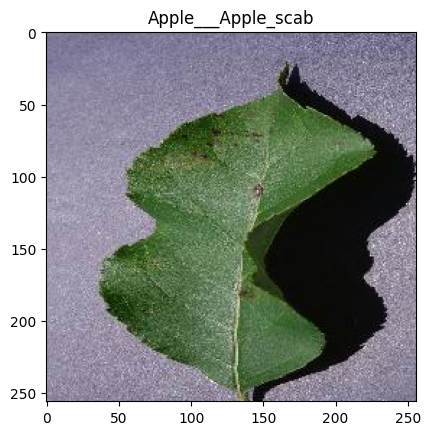

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = 'PlantVillage-Dataset/raw'
classes = os.listdir(os.path.join(dataset_path, 'color')) # List directories within 'color'
print("Classes: ", classes)

# Load and display one sample image
sample_class = classes[0] # This will now be a plant disease class
sample_img_path = os.path.join(dataset_path, 'color', sample_class, os.listdir(os.path.join(dataset_path, 'color', sample_class))[0]) # Corrected path
image = cv2.imread(sample_img_path)

if image is not None: # Check if image was loaded successfully
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(sample_class)
    plt.show()
else:
    print(f"Error loading image from: {sample_img_path}")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


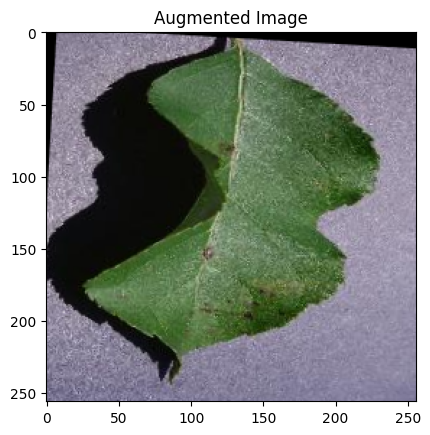

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(), # Changed A.Flip() to A.HorizontalFlip()
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    ToTensorV2()
])

augmented = transform(image=image)
augmented_image = augmented['image']

plt.imshow(augmented_image.permute(1, 2, 0))
plt.title("Augmented Image")
plt.show()

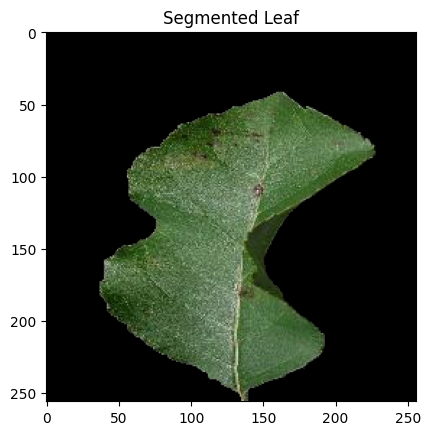

In [ ]:
import numpy as np

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Green leaf mask boundaries (tune if needed)
lower_green = np.array([25, 40, 40])
upper_green = np.array([85, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)

# Clean mask with morphology
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

segmented_leaf = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(segmented_leaf)
plt.title("Segmented Leaf")
plt.show()


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

def preprocess_and_save(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    classes = os.listdir(input_dir)
    for cls in classes:
        class_input_path = os.path.join(input_dir, cls)
        class_output_path = os.path.join(output_dir, cls)
        os.makedirs(class_output_path, exist_ok=True)

        for img_name in os.listdir(class_input_path):
            img_path = os.path.join(class_input_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Augmentation
            augmented = transform(image=img)['image']

            # Convert tensor back to numpy for segmentation
            img_np = augmented.permute(1, 2, 0).cpu().numpy()

            # Segment leaf
            hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
            mask = cv2.inRange(hsv, lower_green, upper_green)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
            segmented = cv2.bitwise_and(img_np, img_np, mask=mask)

            # Save segmented image
            save_path = os.path.join(class_output_path, img_name)
            cv2.imwrite(save_path, cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

preprocess_and_save('PlantVillage-Dataset/raw/color', 'preprocessed_data') # Updated input_dir

In [ ]:
import os
print(os.listdir())


['.config', 'preprocessed_data', 'PlantVillage-Dataset', 'sample_data']


In [ ]:
print(os.listdir('PlantVillage-Dataset'))


['.git', 'utils', 'README_HF.md', 'logs', 'raw', 'data_distribution_for_SVM', 'README.md', 'generate_data_for_SVM.py', 'scripts', 'CITATION.cff', 'plant_village.py', 'generated_for_paper', 'generate_mapstring.py', 'leaf_grouping', 'leaf-map.json', 'generate_lmdb.sh', '.gitignore']


In [ ]:
dataset_path = 'PlantVillage-Dataset/color'


In [ ]:
print(os.listdir('PlantVillage-Dataset'))


['.git', 'utils', 'README_HF.md', 'logs', 'raw', 'data_distribution_for_SVM', 'README.md', 'generate_data_for_SVM.py', 'scripts', 'CITATION.cff', 'plant_village.py', 'generated_for_paper', 'generate_mapstring.py', 'leaf_grouping', 'leaf-map.json', 'generate_lmdb.sh', '.gitignore']


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
import os

for root, dirs, files in os.walk("preprocessed_data"):
    print(root, "->", len(files), "files")


preprocessed_data -> 0 files
preprocessed_data/Apple___Apple_scab -> 630 files
preprocessed_data/Tomato___Septoria_leaf_spot -> 1771 files
preprocessed_data/Potato___healthy -> 152 files
preprocessed_data/Soybean___healthy -> 5090 files
preprocessed_data/Tomato___Tomato_mosaic_virus -> 373 files
preprocessed_data/Tomato___Bacterial_spot -> 2127 files
preprocessed_data/Corn_(maize)___Northern_Leaf_Blight -> 985 files
preprocessed_data/Tomato___Late_blight -> 1909 files
preprocessed_data/Raspberry___healthy -> 371 files
preprocessed_data/Tomato___Early_blight -> 1000 files
preprocessed_data/Apple___Black_rot -> 621 files
preprocessed_data/Apple___healthy -> 1645 files
preprocessed_data/Corn_(maize)___healthy -> 1162 files
preprocessed_data/Grape___Black_rot -> 1180 files
preprocessed_data/Tomato___healthy -> 1591 files
preprocessed_data/Tomato___Spider_mites Two-spotted_spider_mite -> 1676 files
preprocessed_data/Grape___healthy -> 423 files
preprocessed_data/Potato___Early_blight -> 100